# Assignment 2 - MAGIC Data Classification

Simple step-by-step implementation:
1. Load data
2. Balance classes (`g` and `h`)
3. Split into train/test (70/30)
4. Train 4 required models
5. Tune `n_estimators` for AdaBoost and Random Forest
6. Show required metrics and confusion matrices

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

In [2]:
# Settings
RANDOM_STATE = 42

FEATURE_COLUMNS = [
    "fLength", "fWidth", "fSize", "fConc", "fConc1",
    "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist"
]
TARGET_COLUMN = "class"
ALL_COLUMNS = FEATURE_COLUMNS + [TARGET_COLUMN]

# Paths (notebook is inside src/)
project_root = Path("..").resolve()
data_dir = project_root / "data"
raw_data_path = data_dir / "raw" / "magic04.data"
processed_dir = data_dir / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

balanced_path = processed_dir / "processed_balanced.csv"
train_path = processed_dir / "train.csv"
test_path = processed_dir / "test.csv"

print("Data folders are ready.")

Data folders are ready.


In [3]:
# Load raw data
df = pd.read_csv(raw_data_path, header=None, names=ALL_COLUMNS)

print("Data shape:", df.shape)
print("Original class counts:")
print(df[TARGET_COLUMN].value_counts())

Data shape: (19020, 11)
Original class counts:
class
g    12332
h     6688
Name: count, dtype: int64


In [4]:
# Balance classes by downsampling class g to match class h
df_g = df[df[TARGET_COLUMN] == "g"]
df_h = df[df[TARGET_COLUMN] == "h"]

df_g_sampled = df_g.sample(n=len(df_h), random_state=RANDOM_STATE)
balanced_df = pd.concat([df_g_sampled, df_h], axis=0)
balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

balanced_df.to_csv(balanced_path, index=False)

print("Balanced data shape:", balanced_df.shape)
print("Balanced class counts:")
print(balanced_df[TARGET_COLUMN].value_counts())
print("Balanced dataset saved.")

Balanced data shape: (13376, 11)
Balanced class counts:
class
h    6688
g    6688
Name: count, dtype: int64
Balanced dataset saved.


In [5]:
# Split data into train and test (70/30)
X = balanced_df[FEATURE_COLUMNS]
y = balanced_df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_df = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train and test datasets saved.")

Train shape: (9363, 11)
Test shape: (4013, 11)
Train and test datasets saved.


In [6]:
# Tune AdaBoost and Random Forest (only n_estimators)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
n_values = [25, 50, 100, 150, 200, 300]

ada_grid = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=RANDOM_STATE),
    param_grid={"n_estimators": n_values},
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
ada_grid.fit(X_train, y_train)

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid={"n_estimators": n_values},
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best AdaBoost n_estimators:", ada_grid.best_params_["n_estimators"])
print("Best Random Forest n_estimators:", rf_grid.best_params_["n_estimators"])

Best AdaBoost n_estimators: 300
Best Random Forest n_estimators: 200


In [7]:
# Build final models
decision_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
naive_bayes = GaussianNB()
adaboost = ada_grid.best_estimator_
random_forest = rf_grid.best_estimator_

models = {
    "Decision Tree": decision_tree,
    "Naive Bayes": naive_bayes,
    "AdaBoost": adaboost,
    "Random Forest": random_forest
}

best_n = {
    "Decision Tree": "N/A",
    "Naive Bayes": "N/A",
    "AdaBoost": ada_grid.best_params_["n_estimators"],
    "Random Forest": rf_grid.best_params_["n_estimators"]
}

In [8]:
# Evaluate on test set
results = []
conf_matrices = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label="g", zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label="g", zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label="g", zero_division=0)

    results.append({
        "Model": model_name,
        "Best n_estimators": best_n[model_name],
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

    conf_matrices[model_name] = confusion_matrix(y_test, y_pred, labels=["g", "h"])

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Best n_estimators,Accuracy,Precision,Recall,F1-score
0,Random Forest,200,0.863444,0.841047,0.896363,0.867824
1,AdaBoost,300,0.813606,0.817769,0.807175,0.812437
2,Decision Tree,N/A,0.798156,0.796434,0.801196,0.798808
3,Naive Bayes,N/A,0.656616,0.605502,0.899352,0.723737


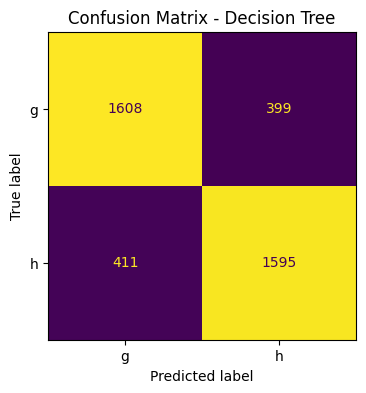

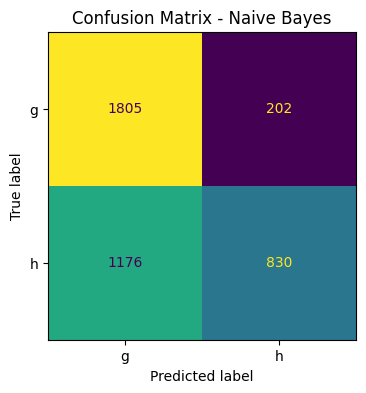

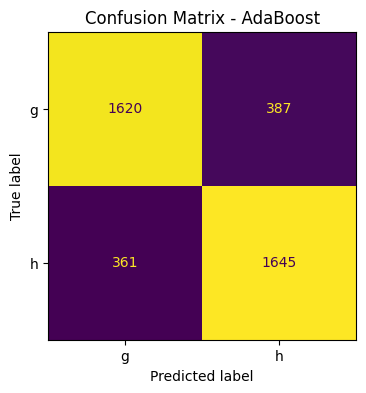

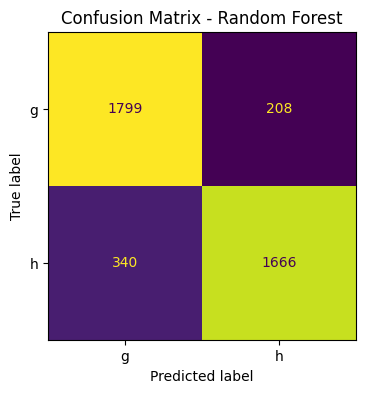

In [9]:
# Show confusion matrices
for model_name in models.keys():
    cm = conf_matrices[model_name]
    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["g", "h"]).plot(ax=ax, colorbar=False)
    ax.set_title("Confusion Matrix - " + model_name)
    plt.show()